# Импрорты и нужные классы

In [1]:
import sys
import os
import torch
import copy
import numpy as np
from dotenv import load_dotenv
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
ENV_PATH = os.path.join(PROJECT_ROOT, ".env")

BASE_DIR = PROJECT_ROOT / "experiments" / "data_chunks_exp"

# sys.path.append('..')
# env_file = os.path.join('..', '.env')
load_dotenv(ENV_PATH)
rowGlam_type = os.environ['ROW_GLAM_TYPE'] # custom or base
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.models.rowGLAM_base import TorchModelBase, PARAMS_BASE
from rows2regionsGLAM.models.rowGLAM_custom import TorchModel, PARAMS

from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from pager.page_model.sub_models.dtype import ImageSegment
from pager.page_model.sub_models import RegionModel, RowsModel

E:\Work\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loger = Loger(os.path.join(BASE_DIR, 'log.txt'))
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# Проверка чтения файла

In [4]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [5]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [6]:
file_names = list(json_true_regions.keys())
file_names.sort()

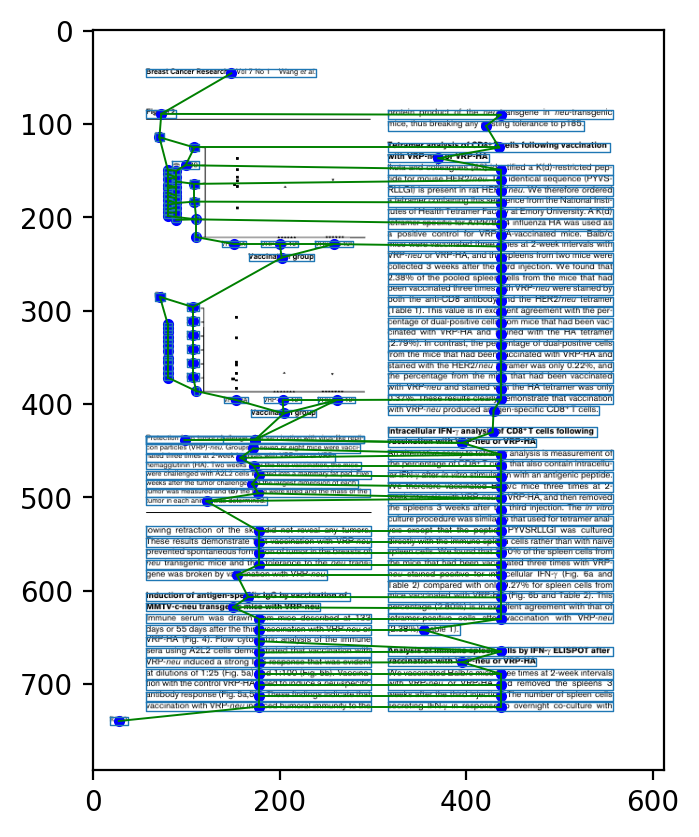

In [7]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Сохранение датасета

In [8]:
dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

In [9]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

# Отрисовска файла из датасета

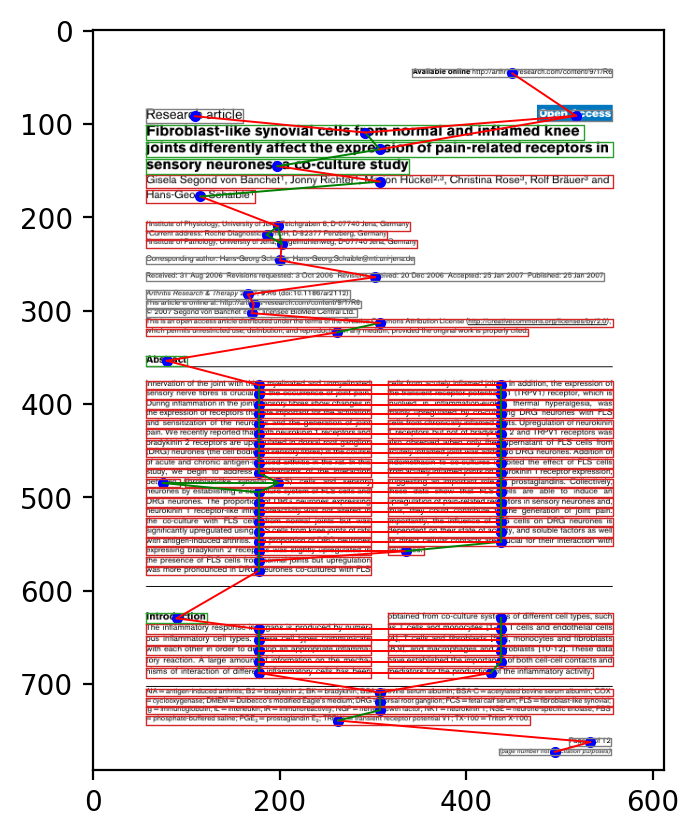

In [10]:
torch_dict2 = dataset[100]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Параметры эксперимента

In [11]:
BATCH_SIZE = [1, 8, 16, 32, 64, 128, 256, 512]
LEARNING_RATE = [0.01, 0.001, 0.0001, 0.00001]

# Вспомогательные функции для сбора метрик

In [12]:
import re
import matplotlib.pyplot as plt
import json
def parse_log(log_path: Path):
    train_losses = []
    val_losses = []

    map_score = None
    f1_row_95 = None

    epoch_pattern = re.compile(
        r"EPOCH\s+#(\d+)\s+([\d.]+)\s+\(VAL:\s+([\d.]+)\)"
    )

    map_pattern = re.compile(
        r"mAP@IoU\[0\.50:0\.95\]\s+:(\d+\.\d+)"
    )

    f1_95_pattern = re.compile(
        r"threshold_95.*?f1_row\s+:(\d+\.\d+)",
        re.DOTALL
    )

    text = log_path.read_text()

    for match in epoch_pattern.finditer(text):
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    map_match = map_pattern.search(text)
    if map_match:
        map_score = float(map_match.group(1))

    f1_match = f1_95_pattern.search(text)
    if f1_match:
        f1_row_95 = float(f1_match.group(1))

    return np.array(train_losses), np.array(val_losses), map_score, f1_row_95

def analyze_curves(train_losses, val_losses):
    best_train_epoch = int(np.argmin(train_losses))

    diff = train_losses - val_losses

    sign_change_idx = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(sign_change_idx) > 0:
        intersection_epoch = int(sign_change_idx[0] + 1)
        intersection_type = "sign_change"
    else:
        intersection_epoch = int(np.argmin(np.abs(diff)))
        intersection_type = "min_distance"

    return best_train_epoch, intersection_epoch, intersection_type


def plot_losses(train_losses, val_losses, intersection_epoch, save_path: Path):
    plt.figure(figsize=(8, 5))

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.axvline(intersection_epoch, linestyle="--", label="Intersection")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# Запуск эксперимента

In [ ]:
for learning_rate in LEARNING_RATE:
    for batch_size in BATCH_SIZE:
        model_name = f'row2region_GLAM_batch{batch_size}_lr{str(learning_rate)[2:]}'
        
        if rowGlam_type == "base":
            model_params = copy.deepcopy(PARAMS_BASE)
        elif rowGlam_type == "custom":
            model_params = copy.deepcopy(PARAMS)
            
        model_params["NodeClasses"] = len(CLASSES)
        
        model_params["epochs"] = 30
        model_params["batch_size"] = batch_size
        model_params["learning_rate"] = learning_rate
        
        # Дисбаланс классов ------------------------------------
        publaynet_imbalance, edge_imbalance = calculate_imbalance(dataset)
        
        model_params['loss_params']['publaynet_imbalance'] = publaynet_imbalance
        model_params['loss_params']['edge_imbalance'] = edge_imbalance

        # Обучение модели ------------------------------------
        exp_name = f"batch{batch_size}_lr{str(learning_rate)[2:]}"
        exp_dir = BASE_DIR / exp_name
        exp_dir.mkdir(parents=True)
        log_path = Path(os.path.join(exp_dir, 'log.txt'))
        loger_exp = Loger(log_path)
        
        trainer_pub = Trainer(conf={"loger": loger_exp, "params": model_params, "model_name": os.path.join(exp_dir, model_name)})
        trainer_pub.start_train(5, dataset)

        # Тестирование ------------------------------------
        model_params['sigmoidEdge'] = True
        if rowGlam_type == "base":
            model = TorchModelBase(model_params)
        elif rowGlam_type == "custom":
            model = TorchModel(model_params)
        
        model.load_state_dict(torch.load(os.path.join(exp_dir, model_name), weights_only=True))
        
        rows_model = RowsModel()
        region_model = RegionModel()
        rows2regions = Rows2Regions({
            'model':model, 
            'tokenizer': RowGLAMTokenizer(),
            'is_merge_extract': True,
            'classes': CLASSES
        })

        tester = Tester(conf={
            "loger": loger_exp, 
            "pdf_manager": pdf_manager, 
            "row_manager": row_manager, 
            "rows_model": rows_model, 
            "region_model": region_model, 
            "rows2regions": rows2regions})
        
        metrics = tester.calculate_target_and_preds(
            test_dataset, 
            name_dataset, 
            name_test_dataset, 
            dataset_path, 
            test_path
        )
        tester.print_result(metrics)
        
        train_losses, val_losses, map_score, f1_row_95 = parse_log(log_path)
        
        best_train_epoch, intersection_epoch, intersection_type = analyze_curves(train_losses, val_losses)
        
        
        plot_path = exp_dir / "loss_curve.png"
        plot_losses(train_losses, val_losses, intersection_epoch, plot_path)
        
        metrics = {
            "mAP_50_95": map_score,
            "f1_row_threshold_95": f1_row_95,
            "best_train_epoch": best_train_epoch,
            "best_train_loss": float(train_losses[best_train_epoch]),
        
            "intersection_epoch": intersection_epoch,
            "intersection_type": intersection_type,
        
            "best_val_loss": float(np.min(val_losses)),
            "best_val_epoch": int(np.argmin(val_losses)),
        }
        
        metrics_path = exp_dir / "metrics.json"
        with open(metrics_path, "w") as f:
            json.dump(metrics, f, indent=4)


            DATASET INFO:
            count row: 10000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([104, 104])
            	 nodes_feature:torch.Size([104, 15])
            	 edges_feature:torch.Size([151, 4])
            	 true_edges:torch.Size([151])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([107, 107])
            	 nodes_feature:torch.Size([107, 15])
            	 edges_feature:torch.Size([108, 4])
            	 true_edges:torch.Size([108])
        node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	1
learning_rate:	0.01
Tag:	[{'in': -1, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[-1, 64, 32]
NodeLinearClassifier:	[-1, 16, 8]
EdgeLinear:	[-1, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0.8, 'node_coef': 0.2, 'publaynet_imb

E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:66: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  warnings.warn(f"Converting sparse tensor to CSR format for more "
E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:70: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()
E:\Work\env\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


'X'ch # 1539 loss=0.0683                                          
100.00 % Batch loss=0.1478                                        

E:\Work\env\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
E:\Work\env\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


'X'ch # 1752 loss=0.0402                                          
'X'ch # 1911 loss=0.0919                                          
'X'ch # 4865 loss=0.0272                                          
'X'ch # 5142 loss=0.0418                                          
'X'ch # 7241 loss=0.0598                                          
'X'ch # 7664 loss=0.0770                                          
'X'ch # 982 loss=0.1037                                           
========== EPOCH #1 ========== (0.1191/0.1160)                    
Время обучения epoch 118.32 сек
'X'ch # 1539 loss=0.0443                                          
'X'ch # 1752 loss=0.0429                                          
'X'ch # 1911 loss=0.0578                                          
'X'ch # 4865 loss=0.0253                                          
'X'ch # 5142 loss=0.0238                                          
'X'ch # 7241 loss=0.0579                                          
'X'ch # 7664 loss=0.0702      

...

45.00 %

Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P6' is an invalid float value
Cannot set gray non-stroke color because /'P7' is an invalid float value
Cannot set gray non-stroke color because /'P8' is an invalid float value


54.50 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


99.00 %